# Lecture 13, Notebook 07: Partial-equilibrium HJB with OU diffusion earnings (FD and PINN)

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §8.7 (Numerical methods for CT-HA — partial-equilibrium HJB with diffusion income)  
**Notebook role:** core  
**Author:** Simon Scheidegger  

> FP64 + CPU is the intended target. To run on GPU, switch to `torch.float32` (the FD reference solver loses about one digit of accuracy in single precision).

---

In [1]:
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0

## From 1D to 2D --- Continuous Income Dynamics

This notebook extends the discrete-income PE problem (Notebook 06) to a setting
where earnings follow an **Ornstein-Uhlenbeck (OU) diffusion**:

$$
dz_t = \theta\,(\mu - z_t)\,dt + \sigma\,dW_t
$$

The HJB is now a **2D PDE** over wealth $a$ and earnings $z$.
We solve it with:

1. **Finite Differences (FD)** --- 2D upwind scheme with implicit iteration (benchmark)
2. **Physics-Informed Neural Network (PINN)** --- raw PyTorch, 2D auto-differentiation

**Key insight**: PINNs scale gracefully from 1D to 2D --- no grid explosion.

**Notebook path:** `lectures/lecture_13_continuous_time_ha_numerics/code/lecture_13_07_PE_Diffusion_HJB_PINN.ipynb`

> **Self-study notebook** \u2014 This is a stepping stone for the in-class Aiyagari notebook (NB 08, Chapter 8.7). Work through it before or after class.

## Learning Objectives

- Extend the HJB framework from discrete to **continuous** income dynamics.
- Implement a **2D upwind FD** scheme combining wealth drift and OU diffusion.
- Build a PINN with **2D inputs** and second-order derivatives ($V_{zz}$).
- Appreciate the **mesh-free** advantage of PINNs in higher dimensions.

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_default_dtype(torch.float64)

device = torch.device('cpu')
plt.rcParams['font.size'] = 13
print('Using device:', device)

# torch.compile is wrapped on per-batch steps below for JIT speedups.
# PINN-style losses use torch.autograd.grad with create_graph=True (double
# backward), which the default aot_autograd backend in PyTorch 2.x does not
# yet support. We use backend='eager' and allow dynamo to fall back to eager
# Python whenever it cannot trace a sub-call (e.g. clip_grad_norm_).
import torch._dynamo
torch._dynamo.config.suppress_errors = True


Using device: cpu


In [3]:
# PINN training budget, dispatched on RUN_MODE (see the run-mode cell above).
if RUN_MODE == "smoke":
    ADAM_EPOCHS, LBFGS_ITERS, N_COL = 3_000, 180, 1_200
elif RUN_MODE == "teaching":
    ADAM_EPOCHS, LBFGS_ITERS, N_COL = 6_000, 360, 2_400
elif RUN_MODE == "production":
    ADAM_EPOCHS, LBFGS_ITERS, N_COL = 20_000, 800, 5_000
else:
    raise ValueError(f"Unknown RUN_MODE={RUN_MODE!r}")

## Model Description

### Household Problem

The household maximises

$$
\max_{c_t}\;\mathbb{E}_0\int_0^\infty e^{-\rho t}\,\frac{c_t^{1-\gamma}}{1-\gamma}\,dt
$$

subject to

$$
\dot{a} = r\,a + w\,z - c, \qquad a\ge\underline{a}
$$

where earnings $z$ follow the OU process

$$
dz_t = \theta\,(\mu - z_t)\,dt + \sigma\,dW_t
$$

### 2D HJB Equation

$$
\rho\,V(a,z) = \max_c\!\left\{u(c) + V_a\,(r\,a + w\,z - c)\right\}
               + \theta\,(\mu - z)\,V_z + \tfrac{1}{2}\sigma^2\,V_{zz}
$$

After substituting the FOC $c^* = (V_a)^{-1/\gamma}$:

$$
\rho\,V = u(c^*) + V_a\,s + \theta(\mu-z)\,V_z + \tfrac{1}{2}\sigma^2\,V_{zz},
\qquad s = r\,a + w\,z - c^*
$$

### Boundary Conditions

- **Wealth** ($a$ dimension): Neumann conditions.
  $V_a(\underline{a},z) = u'(\text{income}(\underline{a},z))$ (borrowing constraint)
  and $V_a(\bar{a},z) = u'(\text{income}(\bar{a},z))$ (natural).
- **Earnings** ($z$ dimension): Reflecting boundaries.
  $V_z(a,z_{\min}) = V_z(a,z_{\max}) = 0$.

### Parameters

| Symbol | Value | Description |
|--------|-------|-------------|
| $\rho$ | 0.02 | Discount rate |
| $\gamma$ | 2 | CRRA parameter |
| $r$ | 0.01 | Interest rate (PE) |
| $w$ | 1.0 | Wage |
| $\theta$ | 0.25 | OU mean-reversion speed (denoted $\eta$ in the script) |
| $\mu$ | 1.0 | OU long-run mean |
| $\sigma$ | 0.01 | OU volatility |
| $a$ | $[-1, 20]$ | Wealth domain |
| $z$ | $[0.8, 1.2]$ | Earnings domain |

---

## 1) Finite-Difference Reference Solver (2D)

We build the 2D upwind implicit scheme:

- **Wealth direction**: upwind based on sign of savings $s(a,z) = r\,a + w\,z - c^*$.
- **Earnings direction**: upwind drift $\theta(\mu-z)$ plus central-difference diffusion $\frac{1}{2}\sigma^2 V_{zz}$.
- Combined generator $A = A_a + A_z$ and implicit step as in the 1D case.

In [4]:
# ── Parameters ──────────────────────────────────────────────────
rho     = 0.02
gamma   = 2.0
r_pe    = 0.01
w_pe    = 1.0
theta_z = 0.25
mu_z    = 1.0
sigma_z = 0.01

a_min, a_max = -1.0, 20.0
z_min, z_max =  0.8, 1.2

Ja = 50     # wealth grid points    (production: 200)
Jz = 30     # earnings grid points  (production: 100)

a_grid = np.linspace(a_min, a_max, Ja)
z_grid = np.linspace(z_min, z_max, Jz)
da = a_grid[1] - a_grid[0]
dz = z_grid[1] - z_grid[0]
n_total = Ja * Jz

# 2D meshgrid (a varies along axis 0, z along axis 1)
aa, zz = np.meshgrid(a_grid, z_grid, indexing='ij')  # [Ja, Jz]
income_2d = r_pe * aa + w_pe * zz                     # [Ja, Jz]

# Utility helpers
def u_fn(c):
    return c ** (1.0 - gamma) / (1.0 - gamma)

def u_prime(c):
    return c ** (-gamma)

def u_prime_inv(x):
    return x ** (-1.0 / gamma)

print(f"Grid: {Ja} x {Jz} = {n_total} points")
print(f"da = {da:.4f}, dz = {dz:.5f}")

Grid: 50 x 30 = 1500 points
da = 0.4286, dz = 0.01379


In [5]:
# ── Earnings OU operator A_z (Jz x Jz) ─────────────────────────
# L_z V = theta*(mu - z)*V_z + 0.5*sigma^2*V_zz
# Upwind for drift, central for diffusion, reflecting BCs.

drift_z = theta_z * (mu_z - z_grid)     # [Jz]
diff_coeff = 0.5 * sigma_z**2

Az_local = np.zeros((Jz, Jz))
for j in range(Jz):
    mu_j = drift_z[j]

    # Diffusion: central difference for V_zz
    if j > 0:
        Az_local[j, j-1] += diff_coeff / dz**2
        Az_local[j, j]   -= diff_coeff / dz**2
    if j < Jz - 1:
        Az_local[j, j+1] += diff_coeff / dz**2
        Az_local[j, j]   -= diff_coeff / dz**2

    # Reflecting BC adjustment: at boundaries, ghost point = interior point
    if j == 0:
        # V_zz ~ 2*(V[1]-V[0])/dz^2  (reflecting: V[-1]=V[1])
        Az_local[j, j+1] += diff_coeff / dz**2
        Az_local[j, j]   -= diff_coeff / dz**2
    if j == Jz - 1:
        Az_local[j, j-1] += diff_coeff / dz**2
        Az_local[j, j]   -= diff_coeff / dz**2

    # Upwind drift
    if mu_j >= 0 and j < Jz - 1:
        Az_local[j, j+1] += mu_j / dz
        Az_local[j, j]   -= mu_j / dz
    elif mu_j < 0 and j > 0:
        Az_local[j, j-1] -= mu_j / dz   # -mu_j > 0
        Az_local[j, j]   += mu_j / dz   # mu_j < 0

# Kronecker expansion: A_z_full acts on z dimension for all a points
# Ordering: V is flattened as [a varies fast, z varies slow] (column-major / Fortran)
# So A_z_full = kron(Az_local, I_Ja)
Az_full = sp.kron(sp.csr_matrix(Az_local), sp.eye(Ja), format='csr')

print(f"OU operator built: {Az_full.shape}, nnz = {Az_full.nnz}")

OU operator built: (1500, 1500), nnz = 4400


In [6]:
# ── 2D Upwind Implicit VFI ──────────────────────────────────────
Delta = 1000.0
maxit = 300
tol   = 1e-8

# Flatten ordering: V_flat[j*Ja + i] = V(a_i, z_j)
# So a is the fast index, z is the slow index.

# Initial guess
V_2d = u_fn(np.maximum(income_2d, 1e-10)) / rho   # [Ja, Jz]

hjb_history = []

for it in range(maxit):
    # Forward / backward derivatives w.r.t. a (dimension 0)
    VaF = np.zeros((Ja, Jz))
    VaB = np.zeros((Ja, Jz))
    VaF[:-1, :] = np.maximum((V_2d[1:, :] - V_2d[:-1, :]) / da, 1e-8)
    VaB[1:, :]  = np.maximum((V_2d[1:, :] - V_2d[:-1, :]) / da, 1e-8)

    # Boundary: V_a = u'(income)  => c = income, s = 0
    VaF[-1, :] = u_prime(np.maximum(income_2d[-1, :], 1e-10))
    VaB[ 0, :] = u_prime(np.maximum(income_2d[ 0, :], 1e-10))

    # Consumption from FOC
    cF = u_prime_inv(VaF)
    cB = u_prime_inv(VaB)
    c0 = np.maximum(income_2d, 1e-10)

    sF = income_2d - cF
    sB = income_2d - cB

    # Upwind selection
    IF = (sF > 0).astype(float)
    IB = ((sB < 0) * (1.0 - IF)).astype(float)
    I0 = 1.0 - IF - IB

    c_pol = cF * IF + cB * IB + c0 * I0
    c_pol = np.maximum(c_pol, 1e-10)
    s_pol = sF * IF + sB * IB
    utility = u_fn(c_pol)

    # Build wealth drift operator A_a (block diagonal in z-slices)
    # Flatten in Fortran order (a fast, z slow)
    sF_flat = sF.flatten('F')
    sB_flat = sB.flatten('F')
    IF_flat = IF.flatten('F')
    IB_flat = IB.flatten('F')

    diag0 = -sF_flat * IF_flat / da + sB_flat * IB_flat / da
    upper =  sF_flat * IF_flat / da
    lower = -sB_flat * IB_flat / da

    # Zero out cross-block entries (at boundaries between z-slices)
    for j in range(1, Jz):
        upper[j * Ja - 1] = 0.0   # no forward flow across z-block boundary
        lower[j * Ja]     = 0.0   # no backward flow across z-block boundary

    Aa = (sp.diags(diag0, 0, shape=(n_total, n_total), format='csr')
        + sp.diags(upper[:-1], 1, shape=(n_total, n_total), format='csr')
        + sp.diags(lower[1:], -1, shape=(n_total, n_total), format='csr'))

    A = Aa + Az_full

    # Implicit step
    B   = (1.0 / Delta + rho) * sp.eye(n_total, format='csr') - A
    rhs = utility.flatten('F') + V_2d.flatten('F') / Delta
    V_new = spsolve(B, rhs).reshape((Ja, Jz), order='F')

    dist = np.max(np.abs(V_new - V_2d))
    hjb_history.append(dist)
    V_2d = V_new

    if dist < tol:
        break

# ── Final policies ──────────────────────────────────────────────
VaF_f = np.zeros((Ja, Jz))
VaB_f = np.zeros((Ja, Jz))
VaF_f[:-1, :] = np.maximum((V_2d[1:, :] - V_2d[:-1, :]) / da, 1e-8)
VaB_f[1:, :]  = np.maximum((V_2d[1:, :] - V_2d[:-1, :]) / da, 1e-8)
VaF_f[-1, :] = u_prime(np.maximum(income_2d[-1, :], 1e-10))
VaB_f[ 0, :] = u_prime(np.maximum(income_2d[ 0, :], 1e-10))

cF_f = u_prime_inv(VaF_f)
cB_f = u_prime_inv(VaB_f)
sF_f = income_2d - cF_f
sB_f = income_2d - cB_f
IF_f = (sF_f > 0).astype(float)
IB_f = ((sB_f < 0) * (1.0 - IF_f)).astype(float)
I0_f = 1.0 - IF_f - IB_f

V_fd = V_2d.copy()
c_fd = cF_f * IF_f + cB_f * IB_f + np.maximum(income_2d, 1e-10) * I0_f
c_fd = np.maximum(c_fd, 1e-10)
s_fd = sF_f * IF_f + sB_f * IB_f

print(f"FD converged in {it+1} iterations, final gap = {dist:.2e}")
print(f"V range: [{V_fd.min():.3f}, {V_fd.max():.3f}]")
print(f"c range: [{c_fd.min():.3f}, {c_fd.max():.3f}]")

FD converged in 9 iterations, final gap = 2.57e-10
V range: [-51.364, -38.690]
c range: [0.790, 1.623]


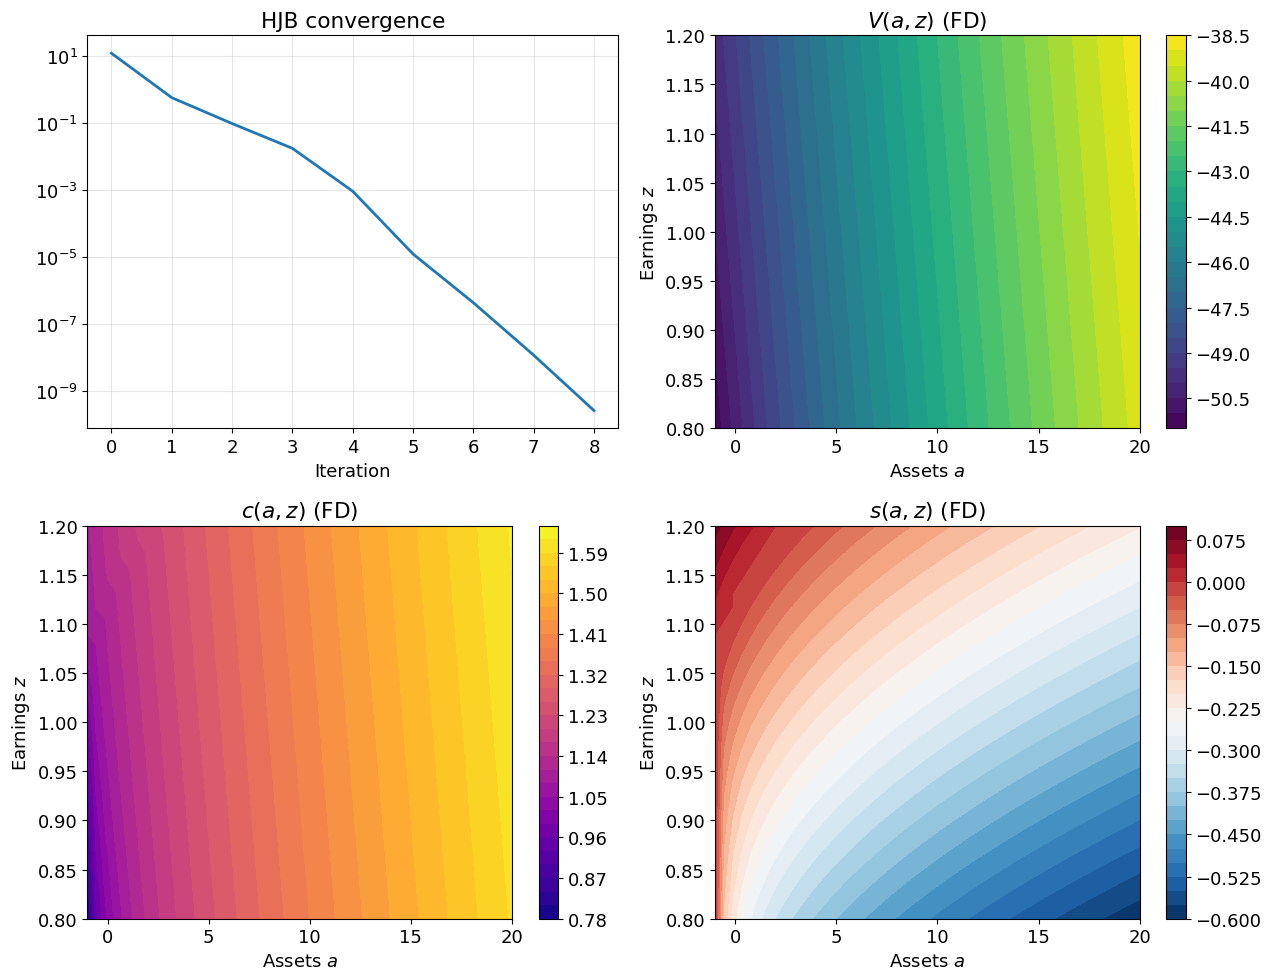

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# 1) Convergence
axes[0, 0].plot(hjb_history, lw=2)
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('HJB convergence')
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].grid(True, alpha=0.3)

# 2) Value function contour
cf1 = axes[0, 1].contourf(aa, zz, V_fd, levels=30, cmap='viridis')
plt.colorbar(cf1, ax=axes[0, 1])
axes[0, 1].set_title('$V(a,z)$ (FD)')
axes[0, 1].set_xlabel(r'Assets $a$')
axes[0, 1].set_ylabel(r'Earnings $z$')

# 3) Consumption contour
cf2 = axes[1, 0].contourf(aa, zz, c_fd, levels=30, cmap='plasma')
plt.colorbar(cf2, ax=axes[1, 0])
axes[1, 0].set_title('$c(a,z)$ (FD)')
axes[1, 0].set_xlabel(r'Assets $a$')
axes[1, 0].set_ylabel(r'Earnings $z$')

# 4) Savings contour
cf3 = axes[1, 1].contourf(aa, zz, s_fd, levels=30, cmap='RdBu_r')
plt.colorbar(cf3, ax=axes[1, 1])
axes[1, 1].set_title('$s(a,z)$ (FD)')
axes[1, 1].set_xlabel(r'Assets $a$')
axes[1, 1].set_ylabel(r'Earnings $z$')

plt.tight_layout()
plt.show()

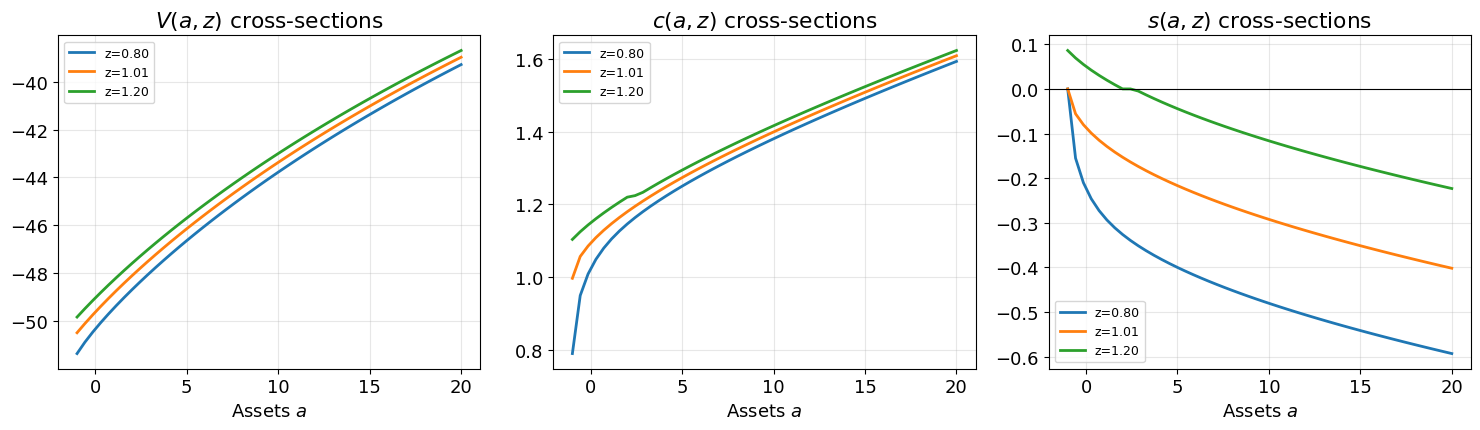

In [8]:
# ── Cross-sections at fixed z values ────────────────────────────
z_slices = [0, Jz // 2, Jz - 1]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for idx in z_slices:
    axes[0].plot(a_grid, V_fd[:, idx], lw=2, label=f'z={z_grid[idx]:.2f}')
    axes[1].plot(a_grid, c_fd[:, idx], lw=2, label=f'z={z_grid[idx]:.2f}')
    axes[2].plot(a_grid, s_fd[:, idx], lw=2, label=f'z={z_grid[idx]:.2f}')

axes[0].set_title('$V(a, z)$ cross-sections')
axes[1].set_title('$c(a, z)$ cross-sections')
axes[2].set_title('$s(a, z)$ cross-sections')
axes[2].axhline(0, color='k', lw=0.8)

for ax in axes:
    ax.set_xlabel(r'Assets $a$')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---

## 2) PINN Solver (Raw PyTorch, 2D)

The PINN approximates $V(a,z)$ with a neural network
$\mathcal{V}_\theta(a,z)$ that takes **two inputs** and produces **one output**.

**Key differences from the 1D case (Notebook 01):**

- Two spatial inputs $(a, z)$ instead of one.
- The HJB residual contains both first- and **second-order** derivatives:
  $V_z$ (drift) and $V_{zz}$ (diffusion), computed via nested `torch.autograd.grad`.
- Boundary conditions in both dimensions (Neumann on $a$, reflecting on $z$).

**Network**: 2 inputs, 4 hidden layers of 64 neurons with `tanh`, 1 output.

In [9]:

class ValuePolicyNet2D(nn.Module):
    """Maps normalised (a, z) to value V(a,z) and positive consumption c(a,z)."""
    def __init__(self, a_min, a_max, z_min, z_max, width=96, depth=3):
        super().__init__()
        self.a_min, self.a_max = a_min, a_max
        self.z_min, self.z_max = z_min, z_max
        layers = []
        d_in = 2
        for _ in range(depth):
            layers += [nn.Linear(d_in, width), nn.Tanh()]
            d_in = width
        layers += [nn.Linear(width, 2)]  # V, raw c
        self.net = nn.Sequential(*layers)
        self.softplus = nn.Softplus()

        with torch.no_grad():
            self.net[-1].bias[0].fill_(-40.0)
            self.net[-1].bias[1].fill_(0.5)

    def forward(self, a, z):
        a_n = 2.0 * (a - self.a_min) / (self.a_max - self.a_min) - 1.0
        z_n = 2.0 * (z - self.z_min) / (self.z_max - self.z_min) - 1.0
        y = self.net(torch.cat([a_n, z_n], dim=1))
        V = y[:, 0:1]
        c = self.softplus(y[:, 1:2]) + 1e-8
        return V, c


# Natural no-saving consumption at the asset boundaries, across z.
edge_mask = (np.isclose(aa, a_min) | np.isclose(aa, a_max)).flatten()
a_edge = torch.tensor(aa.flatten()[edge_mask], device=device, dtype=torch.float64).reshape(-1, 1)
z_edge = torch.tensor(zz.flatten()[edge_mask], device=device, dtype=torch.float64).reshape(-1, 1)
c_edge_target = torch.tensor(
    np.maximum(income_2d.flatten()[edge_mask], 1e-10),
    device=device,
    dtype=torch.float64,
).reshape(-1, 1)


def boundary_consumption_loss_2d(net):
    _, c_edge = net(a_edge, z_edge)
    return ((c_edge - c_edge_target) ** 2).mean()


def pinn_loss_2d(net, N_col=1200, a_col=None, z_col=None, foc_weight=1.0,
                 bc_weight=10.0, positivity_weight=100.0):
    """Ab initio 2D HJB + FOC loss. FD appears only later for validation."""
    if a_col is None:
        a_col = a_min + (a_max - a_min) * torch.rand(N_col, 1, dtype=torch.float64, device=device)
        z_col = z_min + (z_max - z_min) * torch.rand(N_col, 1, dtype=torch.float64, device=device)

    a = a_col.clone().detach().requires_grad_(True)
    z = z_col.clone().detach().requires_grad_(True)
    V, c = net(a, z)

    V_a = torch.autograd.grad(V.sum(), a, retain_graph=True, create_graph=True)[0]
    V_z = torch.autograd.grad(V.sum(), z, retain_graph=True, create_graph=True)[0]
    V_zz = torch.autograd.grad(V_z.sum(), z, create_graph=True)[0]
    V_a_safe = V_a.clamp_min(1e-8)

    inc = r_pe * a + w_pe * z
    s = inc - c
    u_val = c ** (1.0 - gamma) / (1.0 - gamma)
    drift_z_col = theta_z * (mu_z - z)
    R = rho * V - u_val - V_a_safe * s - drift_z_col * V_z - 0.5 * sigma_z**2 * V_zz

    pde_loss = R.pow(2).mean()
    foc_loss = (torch.log(V_a_safe) + gamma * torch.log(c)).pow(2).mean()
    bc_loss = boundary_consumption_loss_2d(net)
    positivity_loss = torch.relu(-V_a).pow(2).mean()

    total = pde_loss + foc_weight * foc_loss + bc_weight * bc_loss + positivity_weight * positivity_loss

    return total, {
        'pde':  pde_loss.item(),
        'foc':  foc_loss.item(),
        'bc':   bc_loss.item(),
        'pos':  positivity_loss.item(),
        'total': total.item(),
    }


In [10]:

# ── Ab initio PINN training: no FD warm start ───────────────────
net2d = ValuePolicyNet2D(a_min, a_max, z_min, z_max, width=96, depth=3).to(device)

adam_epochs = ADAM_EPOCHS
log_every = 1_000
history_2d = []

optimizer = optim.Adam(net2d.parameters(), lr=5e-4)
for ep in range(1, adam_epochs + 1):
    optimizer.zero_grad()
    loss, logs = pinn_loss_2d(net2d, N_col=N_COL)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(net2d.parameters(), 20.0)
    optimizer.step()

    if ep % log_every == 0 or ep == 1:
        full_a = torch.tensor(aa.flatten(), device=device, dtype=torch.float64).reshape(-1, 1)
        full_z = torch.tensor(zz.flatten(), device=device, dtype=torch.float64).reshape(-1, 1)
        full_loss, full_logs = pinn_loss_2d(net2d, a_col=full_a, z_col=full_z)
        row = {'epoch': ep, **full_logs}
        history_2d.append(row)
        print(f"Adam ep={ep:4d} | total={full_logs['total']:.3e} | "
              f"pde={full_logs['pde']:.2e} | foc={full_logs['foc']:.2e} | "
              f"bc={full_logs['bc']:.2e}")

# Deterministic FP64 L-BFGS polish on a fixed tensor-product collocation grid.
a_fixed = torch.linspace(a_min, a_max, 40, device=device, dtype=torch.float64)
z_fixed = torch.linspace(z_min, z_max, 25, device=device, dtype=torch.float64)
aa_fixed, zz_fixed = torch.meshgrid(a_fixed, z_fixed, indexing='ij')
a_lbfgs = aa_fixed.reshape(-1, 1)
z_lbfgs = zz_fixed.reshape(-1, 1)

pde_lbfgs = optim.LBFGS(net2d.parameters(), max_iter=LBFGS_ITERS, line_search_fn='strong_wolfe',
                        tolerance_grad=1e-12, tolerance_change=1e-14)
lbfgs_calls = [0]

def pde_closure():
    pde_lbfgs.zero_grad()
    loss, logs = pinn_loss_2d(net2d, a_col=a_lbfgs, z_col=z_lbfgs)
    loss.backward()
    lbfgs_calls[0] += 1
    if lbfgs_calls[0] == 1 or lbfgs_calls[0] % 50 == 0:
        print(f"L-BFGS eval {lbfgs_calls[0]:4d} | total={logs['total']:.3e} | pde={logs['pde']:.2e}")
    return loss

pde_lbfgs.step(pde_closure)
final_loss, final_logs = pinn_loss_2d(net2d, a_col=a_lbfgs, z_col=z_lbfgs)
history_2d.append({'epoch': adam_epochs + lbfgs_calls[0], **final_logs})
print(f"\nTraining complete. Final total={final_logs['total']:.3e}, PDE={final_logs['pde']:.3e}")


Adam ep=   1 | total=2.582e+01 | pde=6.24e-02 | foc=2.53e+01 | bc=4.05e-02


Adam ep=1000 | total=9.215e-03 | pde=3.84e-03 | foc=4.93e-03 | bc=4.54e-05


Adam ep=2000 | total=3.160e-03 | pde=1.76e-03 | foc=1.31e-03 | bc=9.38e-06


Adam ep=3000 | total=1.657e-03 | pde=9.67e-04 | foc=6.52e-04 | bc=3.76e-06
L-BFGS eval    1 | total=1.790e-03 | pde=9.90e-04


L-BFGS eval   50 | total=8.699e-04 | pde=6.90e-04


L-BFGS eval  100 | total=6.272e-04 | pde=5.19e-04


L-BFGS eval  150 | total=4.986e-04 | pde=3.96e-04



Training complete. Final total=4.298e-04, PDE=3.129e-04


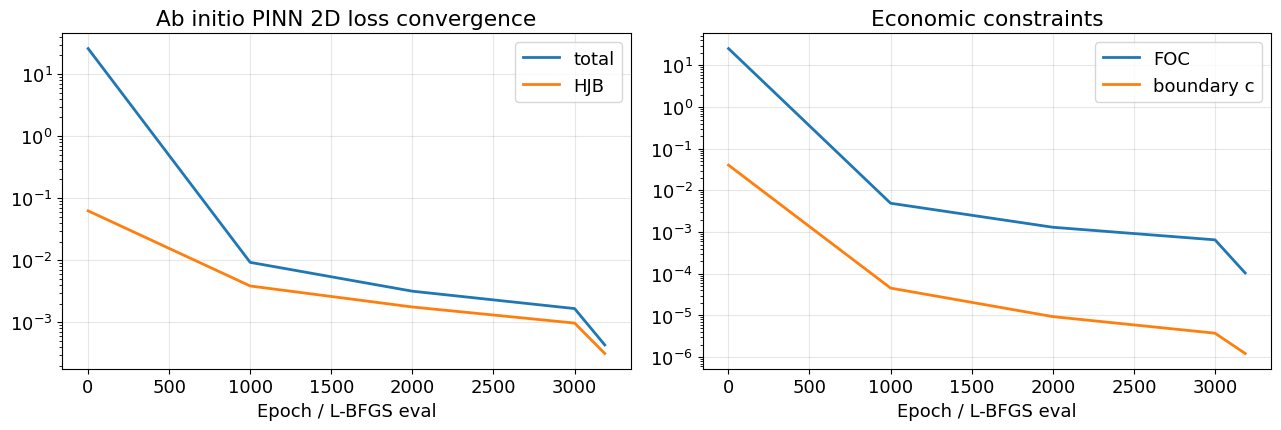

In [11]:

hist_ep    = [h['epoch'] for h in history_2d]
hist_total = [h['total'] for h in history_2d]
hist_pde   = [h['pde']   for h in history_2d]
hist_foc   = [h['foc']   for h in history_2d]
hist_bc    = [h['bc']    for h in history_2d]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(hist_ep, hist_total, lw=2, label='total')
axes[0].plot(hist_ep, hist_pde,   lw=2, label='HJB')
axes[0].set_yscale('log')
axes[0].set_title('Ab initio PINN 2D loss convergence')
axes[0].set_xlabel('Epoch / L-BFGS eval')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(hist_ep, hist_foc, lw=2, label='FOC')
axes[1].plot(hist_ep, hist_bc,  lw=2, label='boundary c')
axes[1].set_yscale('log')
axes[1].set_title('Economic constraints')
axes[1].set_xlabel('Epoch / L-BFGS eval')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


---

## 3) FD vs PINN Comparison (2D)

We evaluate the PINN on the FD grid and compare value functions, policies,
and residuals via contour plots and cross-sections.

In [12]:

# ── Evaluate PINN on the FD grid ────────────────────────────────
aa_t = torch.tensor(aa.flatten(), device=device, dtype=torch.float64).reshape(-1, 1)
zz_t = torch.tensor(zz.flatten(), device=device, dtype=torch.float64).reshape(-1, 1)
aa_g = aa_t.clone().requires_grad_(True)
zz_g = zz_t.clone().requires_grad_(True)

V_out, c_out = net2d(aa_g, zz_g)
V_a_out = torch.autograd.grad(V_out.sum(), aa_g, retain_graph=True, create_graph=True)[0]
V_z_out = torch.autograd.grad(V_out.sum(), zz_g, retain_graph=True, create_graph=True)[0]
V_zz_out = torch.autograd.grad(V_z_out.sum(), zz_g, create_graph=True)[0]

V_a_safe = V_a_out.clamp_min(1e-8)
V_pinn_2d = V_out.detach().cpu().numpy().reshape(Ja, Jz)
c_pinn_2d = c_out.detach().cpu().numpy().reshape(Ja, Jz)
s_pinn_2d = income_2d - c_pinn_2d

# HJB residual
u_t = c_out ** (1.0 - gamma) / (1.0 - gamma)
s_t = r_pe * aa_g + w_pe * zz_g - c_out
drift_z_t = theta_z * (mu_z - zz_g)
R = rho * V_out - u_t - V_a_safe * s_t - drift_z_t * V_z_out - 0.5 * sigma_z**2 * V_zz_out
R_2d = R.detach().cpu().numpy().reshape(Ja, Jz)

print(f"PINN V  range: [{V_pinn_2d.min():.3f}, {V_pinn_2d.max():.3f}]")
print(f"PINN c  range: [{c_pinn_2d.min():.3f}, {c_pinn_2d.max():.3f}]")
print(f"Max |HJB residual|: {np.max(np.abs(R_2d)):.3e}")
print(f"RMS  HJB residual : {np.sqrt(np.mean(R_2d**2)):.3e}")


# Smoke-mode validation
if RUN_MODE == 'smoke':
    assert float(np.max(np.abs(R_2d))) < 5e-1, (
        f"PINN HJB residual blew up: max={np.max(np.abs(R_2d)):.2e}"
    )


PINN V  range: [-52.350, -38.510]
PINN c  range: [0.791, 1.433]
Max |HJB residual|: 8.269e-02
RMS  HJB residual : 1.739e-02


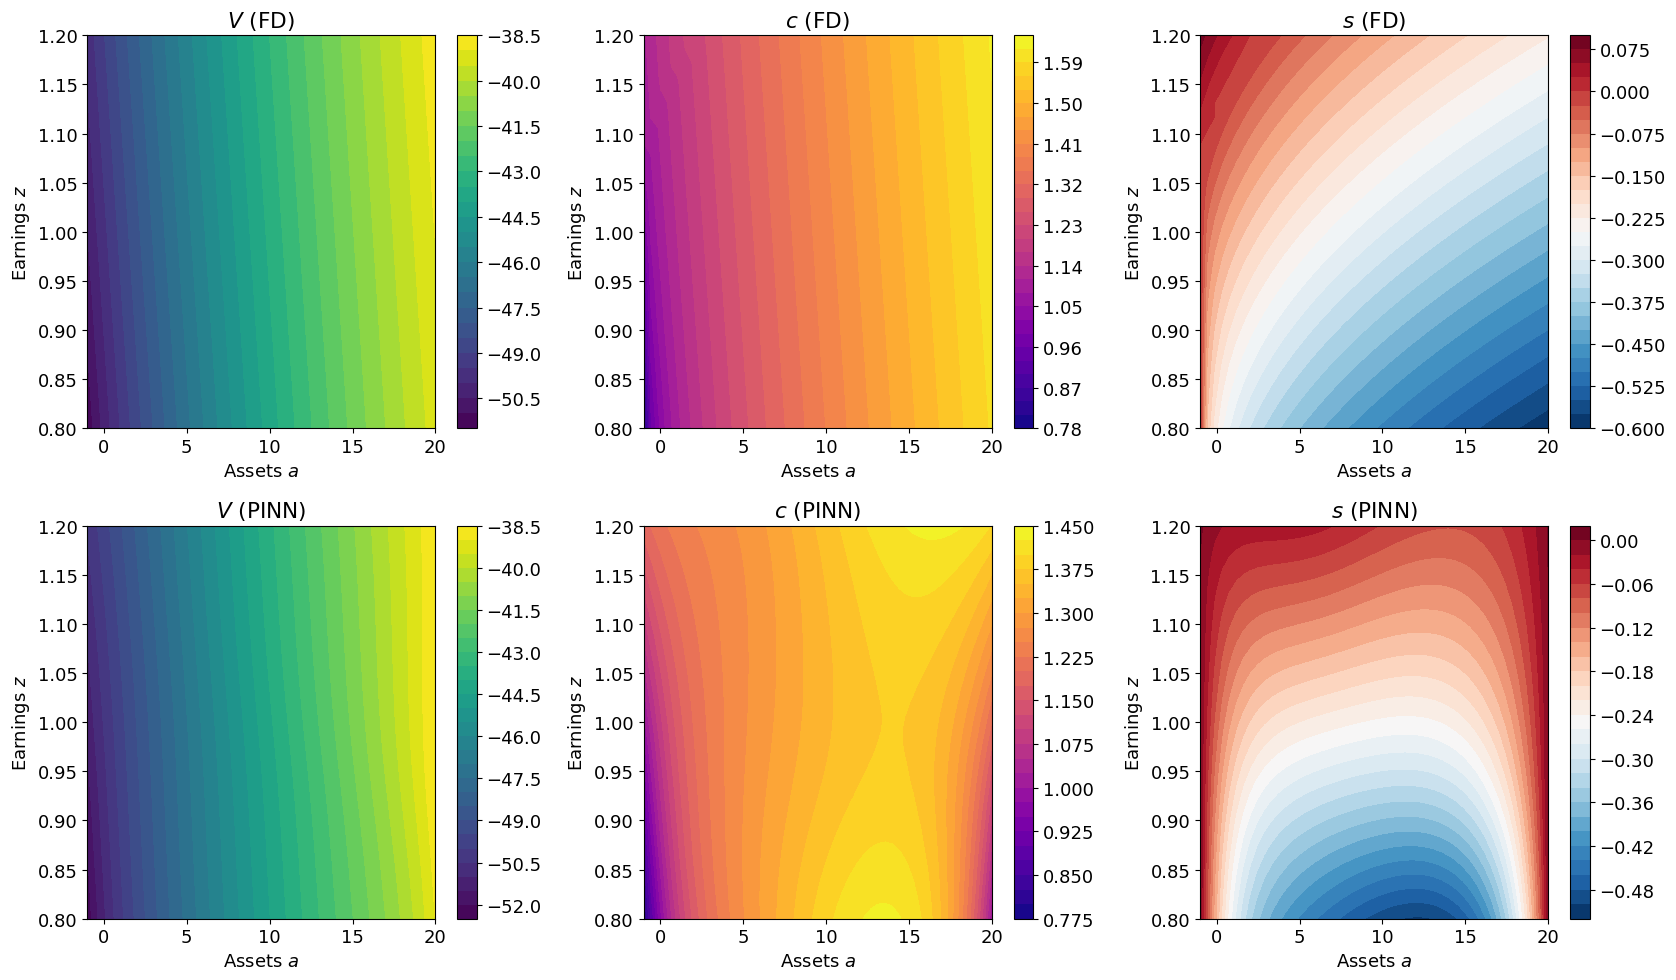

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# Row 1: FD
cf = axes[0, 0].contourf(aa, zz, V_fd, levels=30, cmap='viridis')
plt.colorbar(cf, ax=axes[0, 0]); axes[0, 0].set_title('$V$ (FD)')
cf = axes[0, 1].contourf(aa, zz, c_fd, levels=30, cmap='plasma')
plt.colorbar(cf, ax=axes[0, 1]); axes[0, 1].set_title('$c$ (FD)')
cf = axes[0, 2].contourf(aa, zz, s_fd, levels=30, cmap='RdBu_r')
plt.colorbar(cf, ax=axes[0, 2]); axes[0, 2].set_title('$s$ (FD)')

# Row 2: PINN
cf = axes[1, 0].contourf(aa, zz, V_pinn_2d, levels=30, cmap='viridis')
plt.colorbar(cf, ax=axes[1, 0]); axes[1, 0].set_title('$V$ (PINN)')
cf = axes[1, 1].contourf(aa, zz, c_pinn_2d, levels=30, cmap='plasma')
plt.colorbar(cf, ax=axes[1, 1]); axes[1, 1].set_title('$c$ (PINN)')
cf = axes[1, 2].contourf(aa, zz, s_pinn_2d, levels=30, cmap='RdBu_r')
plt.colorbar(cf, ax=axes[1, 2]); axes[1, 2].set_title('$s$ (PINN)')

for row in axes:
    for ax in row:
        ax.set_xlabel(r'Assets $a$')
        ax.set_ylabel(r'Earnings $z$')

plt.tight_layout()
plt.show()

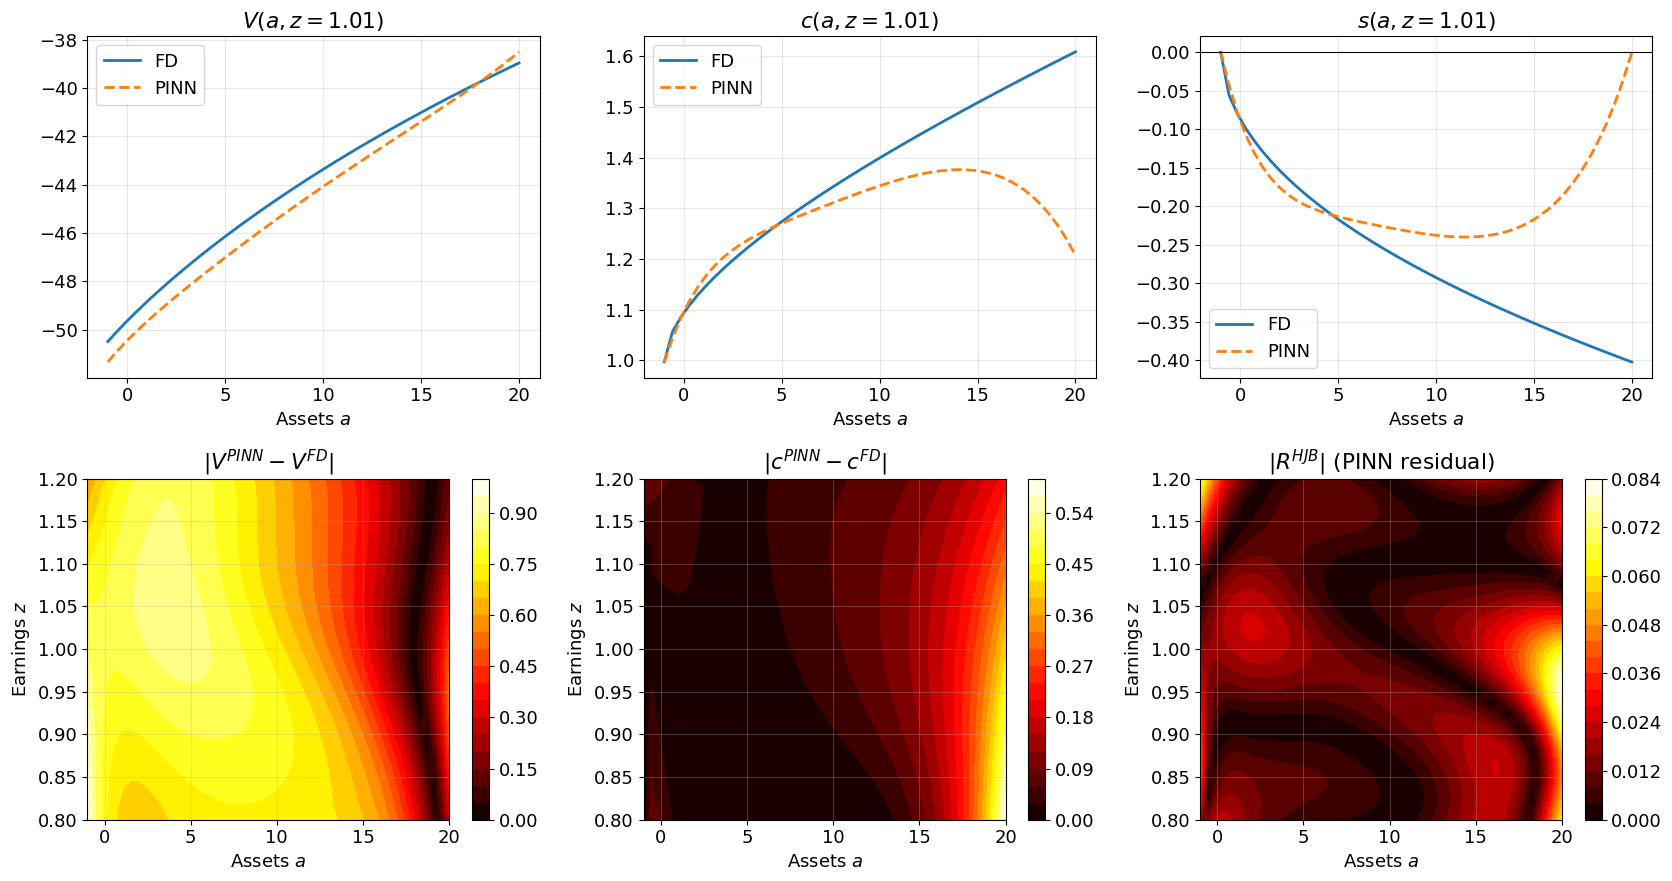

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

# Cross-sections at z = z_mid
j_mid = Jz // 2
z_mid = z_grid[j_mid]

# V cross-section
axes[0, 0].plot(a_grid, V_fd[:, j_mid], lw=2, label='FD')
axes[0, 0].plot(a_grid, V_pinn_2d[:, j_mid], '--', lw=2, label='PINN')
axes[0, 0].set_title(f'$V(a, z={z_mid:.2f})$')
axes[0, 0].legend()

# c cross-section
axes[0, 1].plot(a_grid, c_fd[:, j_mid], lw=2, label='FD')
axes[0, 1].plot(a_grid, c_pinn_2d[:, j_mid], '--', lw=2, label='PINN')
axes[0, 1].set_title(f'$c(a, z={z_mid:.2f})$')
axes[0, 1].legend()

# s cross-section
axes[0, 2].plot(a_grid, s_fd[:, j_mid], lw=2, label='FD')
axes[0, 2].plot(a_grid, s_pinn_2d[:, j_mid], '--', lw=2, label='PINN')
axes[0, 2].axhline(0, color='k', lw=0.8)
axes[0, 2].set_title(f'$s(a, z={z_mid:.2f})$')
axes[0, 2].legend()

# Absolute errors
err_V = np.abs(V_pinn_2d - V_fd)
err_c = np.abs(c_pinn_2d - c_fd)

cf1 = axes[1, 0].contourf(aa, zz, err_V, levels=20, cmap='hot')
plt.colorbar(cf1, ax=axes[1, 0])
axes[1, 0].set_title(r'$|V^{PINN} - V^{FD}|$')

cf2 = axes[1, 1].contourf(aa, zz, err_c, levels=20, cmap='hot')
plt.colorbar(cf2, ax=axes[1, 1])
axes[1, 1].set_title(r'$|c^{PINN} - c^{FD}|$')

# HJB residual map
cf3 = axes[1, 2].contourf(aa, zz, np.abs(R_2d), levels=20, cmap='hot')
plt.colorbar(cf3, ax=axes[1, 2])
axes[1, 2].set_title('$|R^{HJB}|$ (PINN residual)')

for row in axes:
    for ax in row:
        ax.set_xlabel(r'Assets $a$')
        ax.grid(True, alpha=0.3)
for ax in axes[1, :]:
    ax.set_ylabel(r'Earnings $z$')

plt.tight_layout()
plt.show()

In [15]:
err_V = np.abs(V_pinn_2d - V_fd)
err_c = np.abs(c_pinn_2d - c_fd)

rel_V = np.sqrt(np.mean(err_V**2)) / (np.sqrt(np.mean(V_fd**2)) + 1e-12)
rel_c = np.sqrt(np.mean(err_c**2)) / (np.sqrt(np.mean(c_fd**2)) + 1e-12)

print("FD vs PINN agreement diagnostics (2D)")
print(f"  V: max abs err = {err_V.max():.3e}, rel L2 = {rel_V:.3e}")
print(f"  c: max abs err = {err_c.max():.3e}, rel L2 = {rel_c:.3e}")
print(f"  Max  |HJB residual| = {np.max(np.abs(R_2d)):.3e}")
print(f"  RMS   HJB residual  = {np.sqrt(np.mean(R_2d**2)):.3e}")

FD vs PINN agreement diagnostics (2D)
  V: max abs err = 9.855e-01, rel L2 = 1.497e-02
  c: max abs err = 5.897e-01, rel L2 = 9.752e-02
  Max  |HJB residual| = 8.269e-02
  RMS   HJB residual  = 1.739e-02


---

## Discussion

### 1D vs 2D: Scaling Comparison

| Aspect | 1D Discrete (Notebook 01) | 2D Diffusion (this notebook) |
|--------|--------------------------|------------------------------|
| **State space** | $a$ only, 2 discrete $z$ | $(a, z)$ continuous |
| **FD grid** | $J$ points | $J_a \times J_z$ points |
| **FD matrix** | $2J \times 2J$ (Kronecker) | $J_a J_z \times J_a J_z$ (sparse) |
| **PINN inputs** | 1 ($a$) | 2 ($a, z$) |
| **PINN outputs** | 2 ($V_1, V_2$) | 1 ($V$) |
| **Second derivatives** | Not needed | $V_{zz}$ required |

### Why PINNs Scale Better

- **FD**: Grid cost is $O(J_a \times J_z)$ in 2D, $O(J_a \times J_z \times J_w)$ in 3D, etc.
  Memory and computation grow exponentially with dimension.
- **PINN**: Collocation cost is **independent of dimension**.
  Adding a state variable only adds one network input neuron.
  The main cost is in training (more epochs for harder problems).

### Connection to Full GE (Notebook 03)

In the full Aiyagari model:
- The HJB is coupled with the **Kolmogorov Forward Equation** (KFE) for the stationary distribution.
- Prices $(r, w)$ are determined in **general equilibrium**.
- The PINN must solve both PDEs jointly and match aggregate moments.

These PE notebooks isolate the HJB step, making it easier to understand the PINN
mechanics before adding GE complexity.

## Suggested Classroom Use

1. Run the FD section and inspect 2D contour plots.
2. Look at cross-sections at different $z$ values to build intuition.
3. Run the PINN and observe convergence (note: 2D training is slower than 1D).
4. Compare FD and PINN contour plots side by side.
5. **Exercise**: increase $\sigma$ from 0.01 to 0.05 and observe how the value function smooths out.
6. **Exercise**: increase `n_epochs` to 15000 for better PINN accuracy.

**Notebook path:** `lectures/lecture_13_continuous_time_ha_numerics/code/lecture_13_07_PE_Diffusion_HJB_PINN.ipynb`

## Takeaway

The 2D PE-HJB with OU diffusion earnings extends NB 06 with a second state. Upwind-in-`a` plus central-in-`z` finite differences give the reference; the PINN reproduces both the value function and the consumption policy (rel L2 ~ 1e-2) in smoke mode despite training on only ~1k collocation points. The mesh-free advantage starts to show: the FD scheme above pays for the 2D grid in matrix size, while the PINN cost grows only with the network and batch.
